In [13]:
!pip install linearmodels
import pandas as pd
import scipy.stats as sts
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.diagnostic as sms
from statsmodels.iolib.summary2 import summary_col
from linearmodels.iv import IV2SLS
import warnings

warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv('rent_moscow_model_ready.csv', sep=';')

In [15]:
df.isna().sum()

,0
listing_id,0
url,0
scrape_date,0
rent,0
ln_rent,0
rent_per_sqm,0
ln_rent_per_sqm,0
area,0
ln_area,0
rooms,2


In [16]:
df=df.dropna()

In [17]:
features=['rent', 'ln_rent', 'rent_per_sqm', 'ln_rent_per_sqm', 'area',
          'ln_area', 'rooms', 'floor', 'total_floors', 'floor_ratio', 'floor_category',
          'okrug', 'metro_walk_min', 'metro_distance_to_center_km', 'repair_group', 'furnished_dummy', 'amenities_group', 'is_apartment_text',
          'housing_class_group', 'building_services_group', 'author_type', 'far_from_metro']

Создание бинарной переменной для проверки гипотезы

In [18]:
df['far_from_metro']=df['metro_walk_min']>=10

In [19]:
df['far_from_metro']=df['far_from_metro'].astype(int)

# Описательные статистики для зависимой переменной (стоимость аренды жилья в Москве) и ее логарифма.

In [20]:
df[['rent', 'ln_rent']].describe()

,rent,ln_rent
count,2153.000000,2153.000000
mean,148575.316767,11.741642
std,89395.951260,0.576563
min,30000.000000,10.308953
25%,80000.000000,11.289782
50%,123600.000000,11.724806
75%,190000.000000,12.154779
max,400000.000000,12.899220


# Subplots для распределения и боксплотов стоимости аренды и ее логарифма, а также диаграммы рассеяния для стоимости аренды (и ее логарифма) и времени до метро.

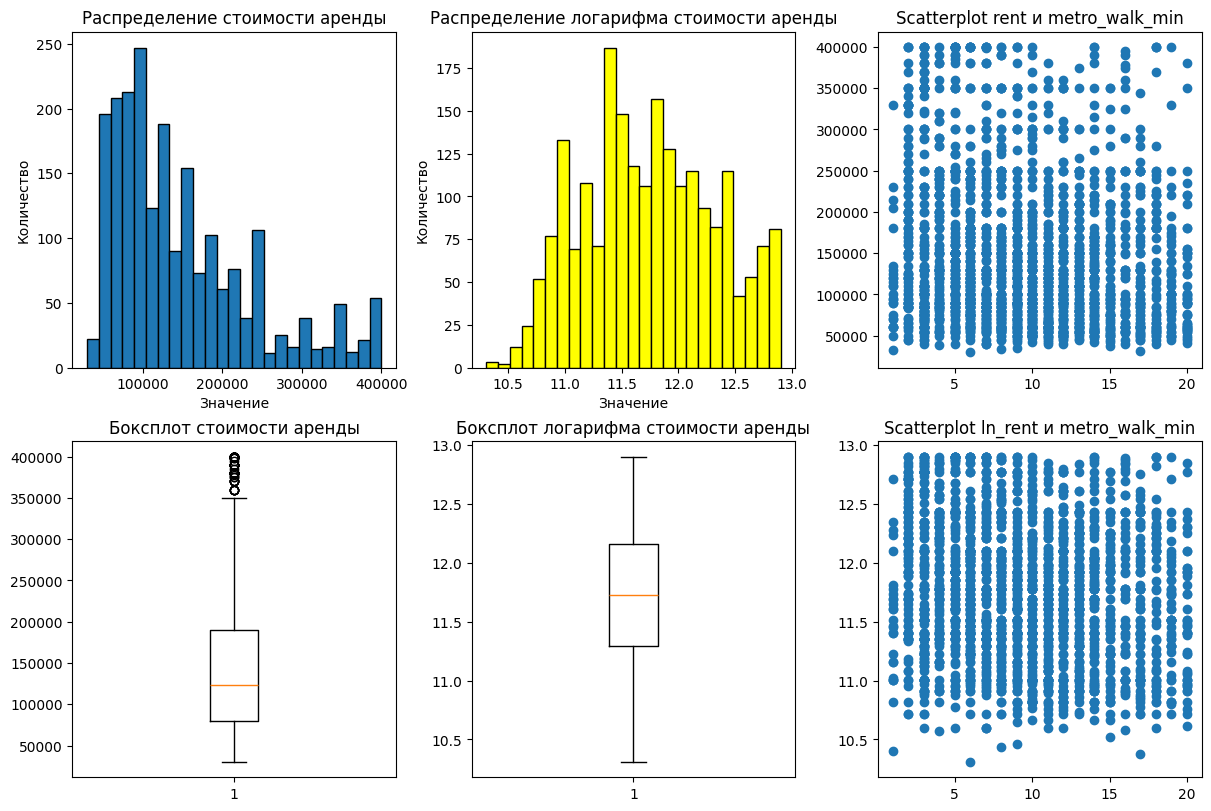

In [21]:
fig, axes = plt.subplots(2, 3, constrained_layout=True, figsize=(12, 8))

axes[0, 0].set_title('Распределение стоимости аренды')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].hist(df['rent'], bins=25, edgecolor='black')

axes[0, 1].set_title('Распределение логарифма стоимости аренды')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_xlabel('Значение')
axes[0, 1].hist(df['ln_rent'], bins=25, edgecolor='black', color='yellow')


axes[0, 2].set_title('Scatterplot rent и metro_walk_min')
axes[0, 2].scatter(df['metro_walk_min'], df['rent'])

axes[1, 0].set_title('Боксплот стоимости аренды')
axes[1, 0].boxplot(df['rent'])

axes[1, 1].set_title('Боксплот логарифма стоимости аренды')
axes[1, 1].boxplot(df['ln_rent'])

axes[1, 2].set_title('Scatterplot ln_rent и metro_walk_min')
axes[1, 2].scatter(df['metro_walk_min'], df['ln_rent'])

plt.show()

# Корреляционная карта переменных.

<Axes: >

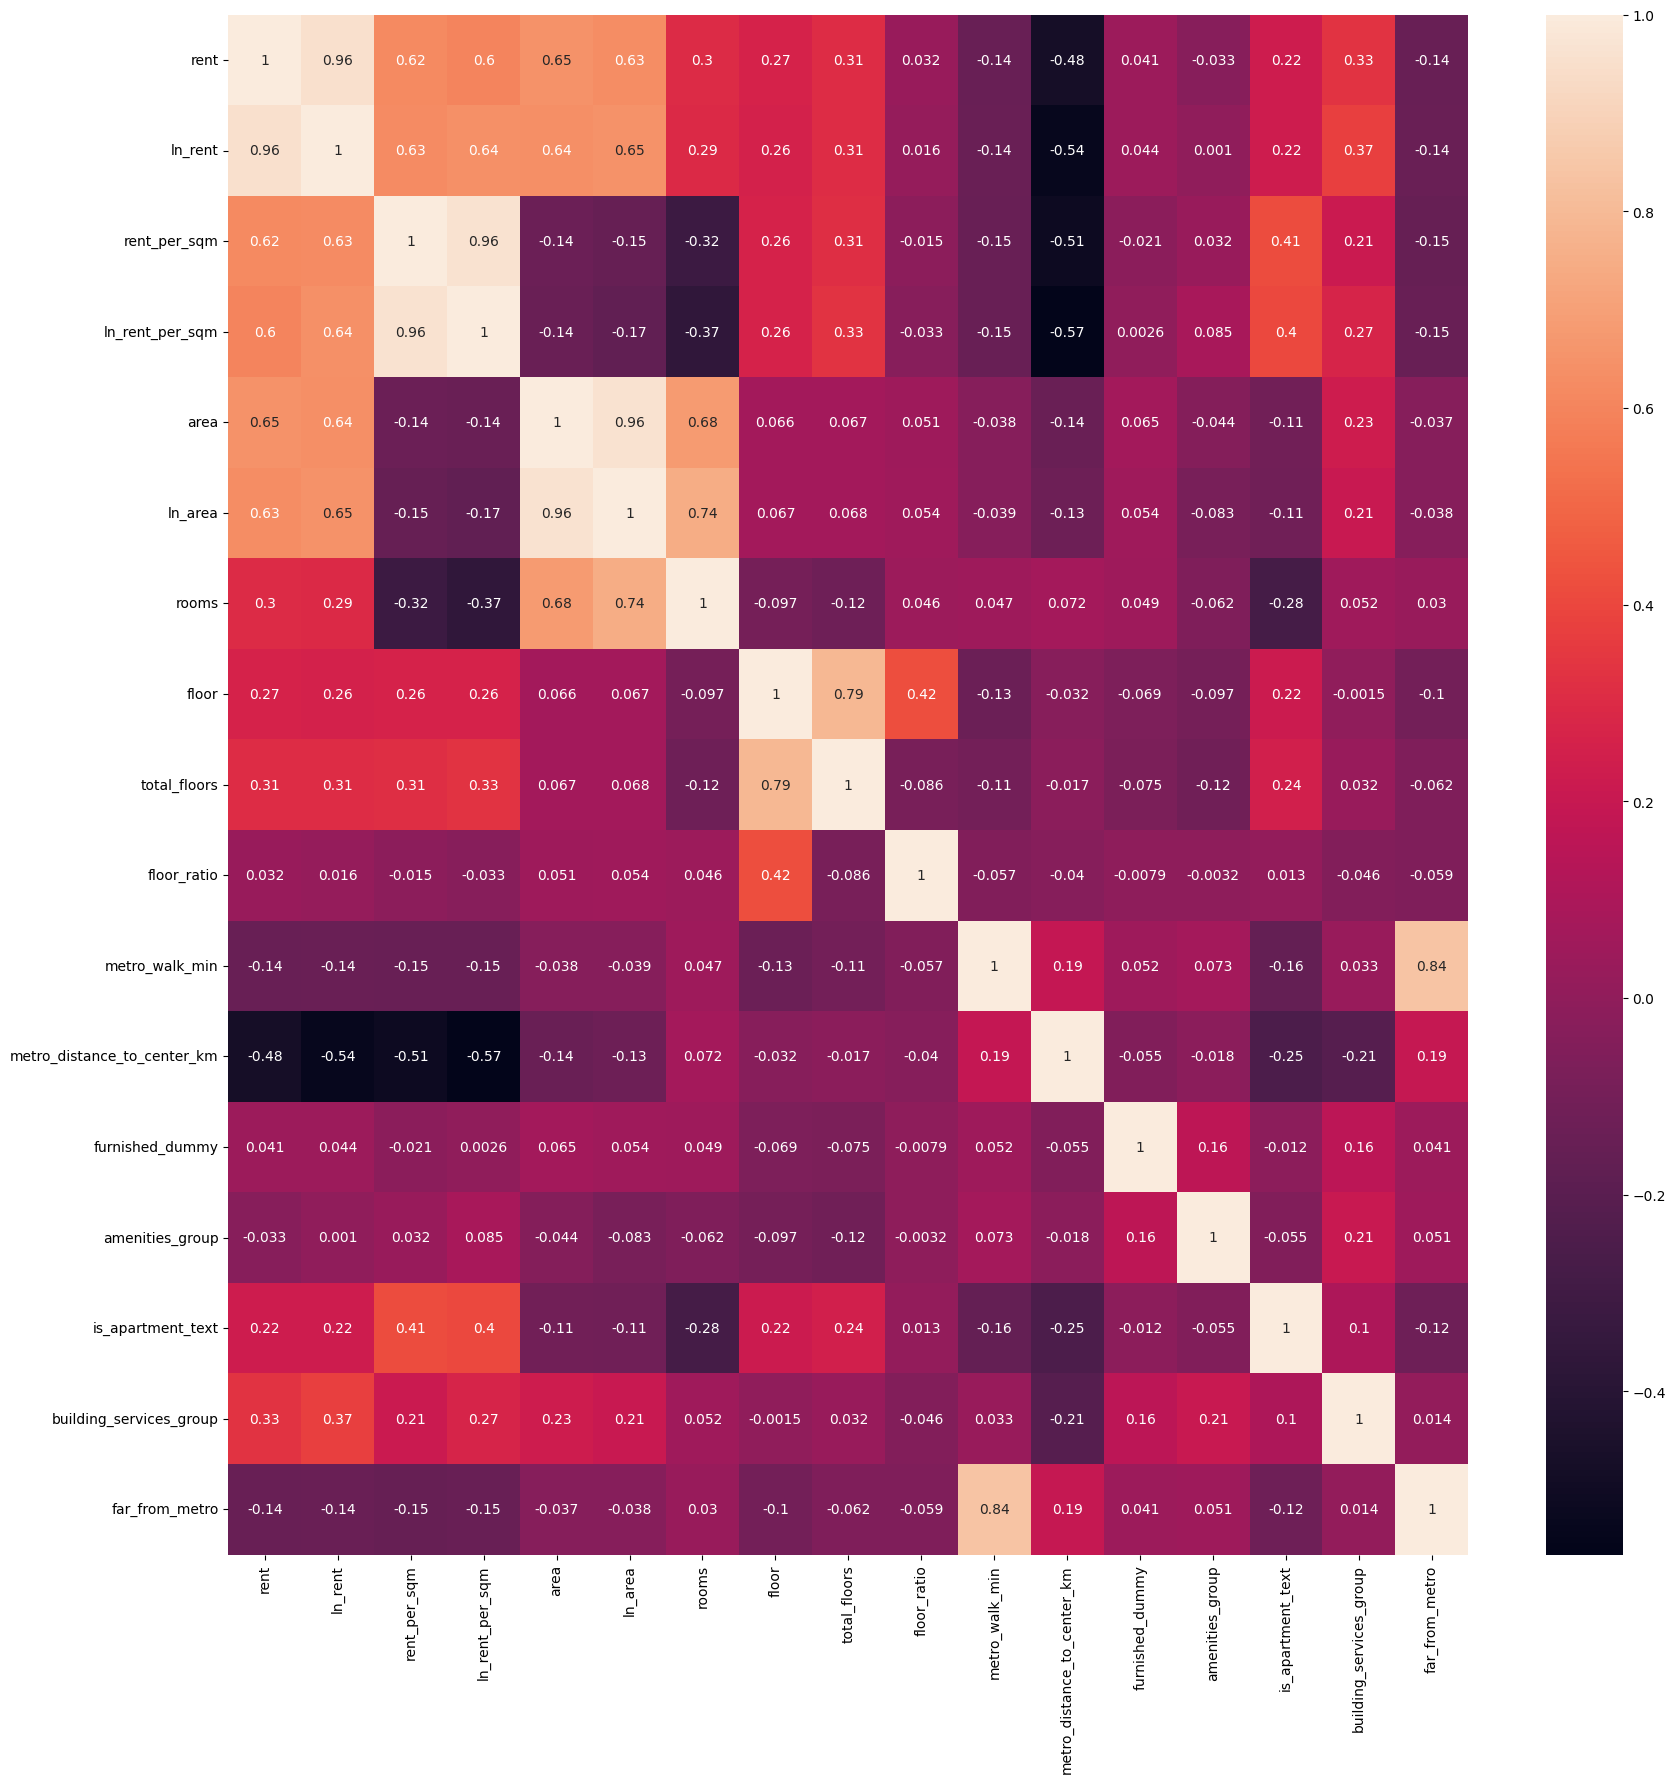

In [22]:
plt.figure(figsize=(20,20))
sns.heatmap(df[features].select_dtypes(include=['int64', 'float64']).corr(), annot=True)

# Распределения категориальных характеристик объектов аренды (число комнат, удаленность от метро, меблированность, группы удобств и сервисов здания).

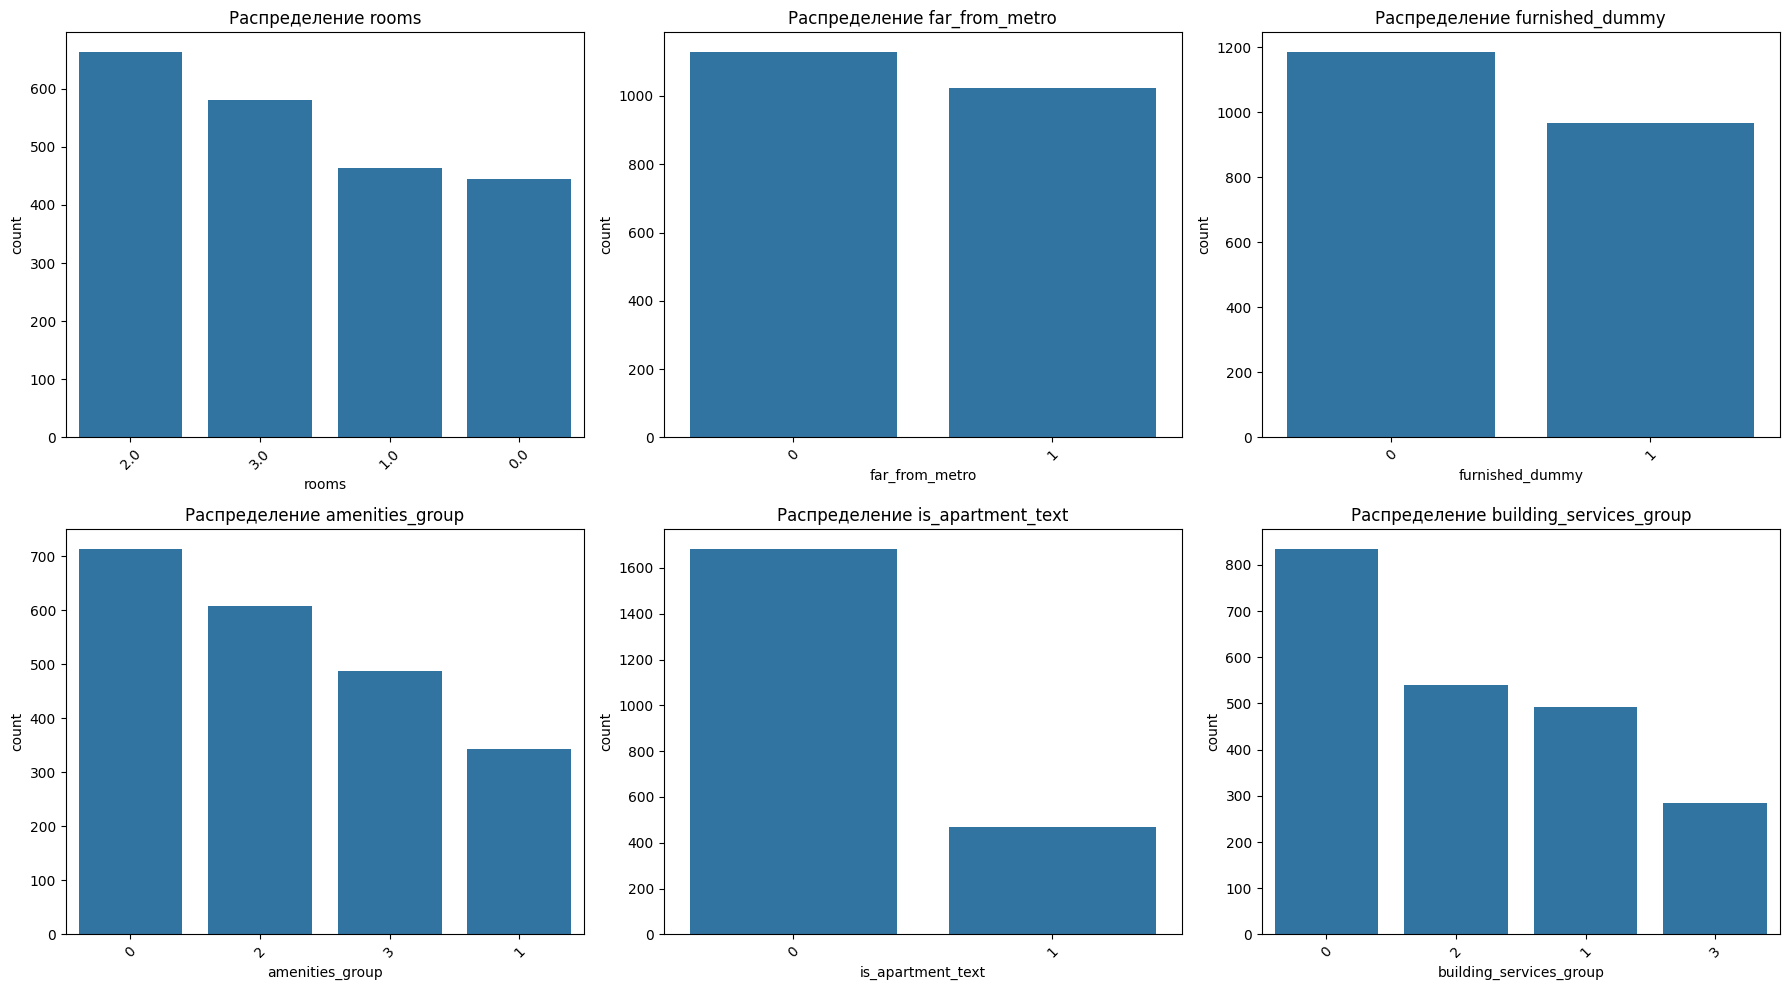

In [23]:
cat_vars = ['rooms', 'far_from_metro', 'furnished_dummy', 'amenities_group', 'is_apartment_text', 'building_services_group']
n = len(cat_vars)
cols = 3
rows = (n + cols - 1) // cols

plt.figure(figsize=(cols * 6, rows * 5))
for i, var in enumerate(cat_vars, 1):
    plt.subplot(rows, cols, i)
    order = df[var].value_counts().index
    sns.countplot(data=df, x=var, order=order)
    plt.title(f'Распределение {var}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Эмпирические распределения стоимости аренды за квадратный метр и её логарифма: гистограммы и боксплоты.

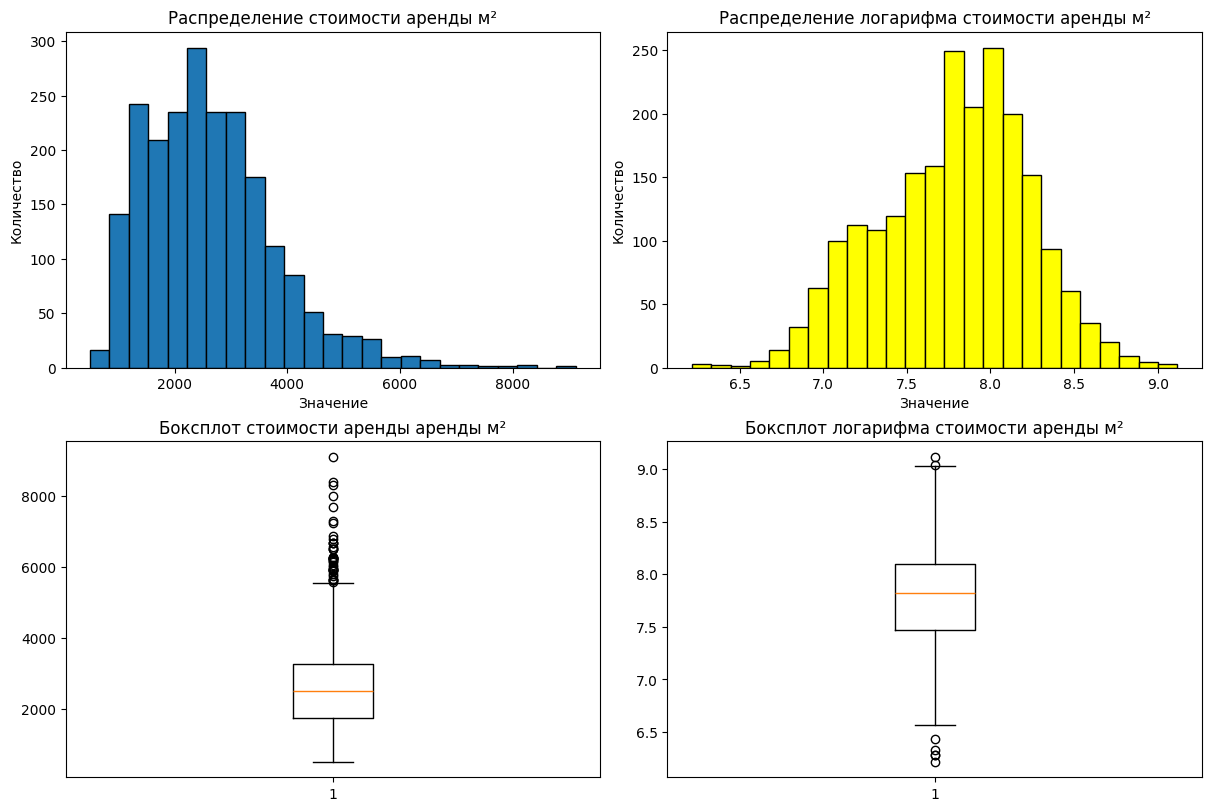

In [24]:
fig, axes = plt.subplots(2, 2, constrained_layout=True, figsize=(12, 8))

axes[0, 0].set_title('Распределение стоимости аренды м²')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].hist(df['rent_per_sqm'], bins=25, edgecolor='black')

axes[0, 1].set_title('Распределение логарифма стоимости аренды м²')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_xlabel('Значение')
axes[0, 1].hist(df['ln_rent_per_sqm'], bins=25, edgecolor='black', color='yellow')

axes[1, 0].set_title('Боксплот стоимости аренды аренды м²')
axes[1, 0].boxplot(df['rent_per_sqm'])

axes[1, 1].set_title('Боксплот логарифма стоимости аренды м²')
axes[1, 1].boxplot(df['ln_rent_per_sqm'])
plt.show()

In [25]:
cols_model = ['ln_rent', 'metro_walk_min', 'area', 'ln_area', 'area_sq', 'far_from_metro',
    'rooms', 'floor_ratio', 'metro_distance_to_center_km', 'okrug',
    'repair_group', 'furnished_dummy', 'amenities_group', 'is_apartment_text',
    'housing_class_group', 'building_services_group', 'author_type']


In [26]:
df_clean=df

In [27]:
df_clean[['rent', 'ln_rent']].describe()

,rent,ln_rent
count,2153.000000,2153.000000
mean,148575.316767,11.741642
std,89395.951260,0.576563
min,30000.000000,10.308953
25%,80000.000000,11.289782
50%,123600.000000,11.724806
75%,190000.000000,12.154779
max,400000.000000,12.899220


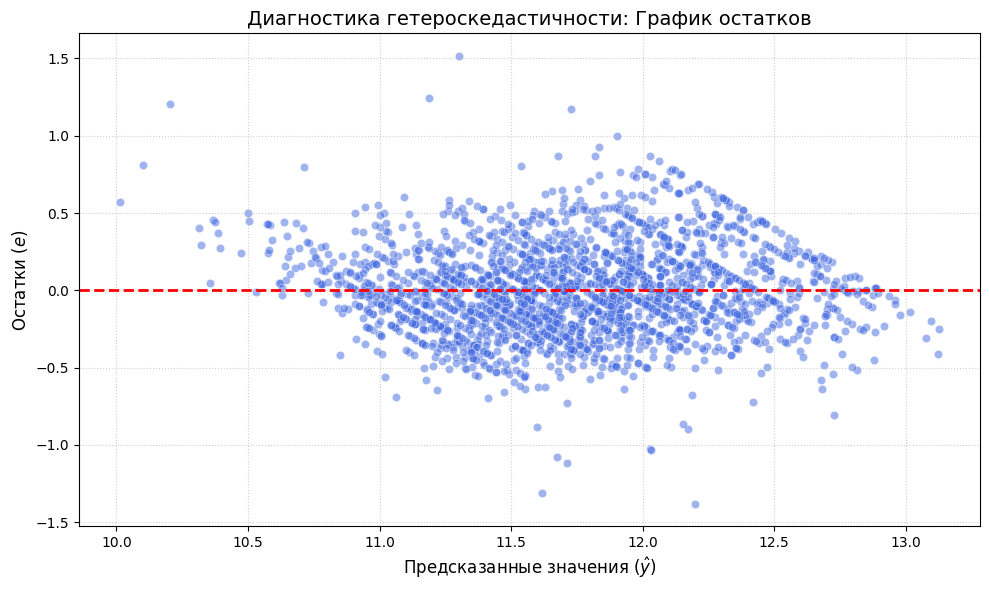

In [28]:
features = ['ln_area', 'rooms', 'floor', 'total_floors', 'floor_ratio',
    'metro_walk_min', 'metro_distance_to_center_km', 'furnished_dummy',
    'C(amenities_group)', 'C(is_apartment_text)', 'C(building_services_group)',
    'far_from_metro']

formula = f"ln_rent ~ {' + '.join(features)}"

all_cols = ['ln_rent'] + [f.replace('C(', '').replace(')', '') for f in features]
df_model = df[all_cols].dropna()

model = smf.ols(formula, data=df_model).fit()
y_hat = model.fittedvalues  # Предсказанные значения (fitted values)
residuals = model.resid      # Остатки (residuals)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_hat, y=residuals, alpha=0.5, color='royalblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.title('Диагностика гетероскедастичности: График остатков', fontsize=14)
plt.xlabel('Предсказанные значения ($\hat{y}$)', fontsize=12)
plt.ylabel('Остатки ($e$)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [29]:
features = [
    'ln_area', 'rooms', 'floor', 'total_floors', 'floor_ratio',
    'metro_walk_min', 'metro_distance_to_center_km', 'furnished_dummy',
    'C(amenities_group)', 'C(is_apartment_text)', 'C(building_services_group)',
    'far_from_metro'
]

formula = f"ln_rent ~ {' + '.join(features)}"
all_cols = ['ln_rent'] + [f.replace('C(', '').replace(')', '') for f in features]
df_model = df[all_cols].dropna()

model = smf.ols(formula, data=df_model).fit()
test_results = sms.het_breuschpagan(model.resid, model.model.exog)

labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'p-value']
print("=== Результаты теста Бройша-Пагана ===")
for label, value in zip(labels, test_results):
    print(f'{label:30}: {value:.4f}')

alpha = 0.05
p_value = test_results[1]

print("\nИнтерпретация:")
if p_value < alpha:
    print(f"P-value ({p_value:.4f}) < {alpha}. Нулевая гипотеза ОТВЕРГАЕТСЯ.")
    print("В модели присутствует гетероскедатичность.")
else:
    print(f"P-value ({p_value:.4f}) > {alpha}. Нет оснований отвергать нулевую гипотезу.")
    print("Ошибки гомоскедатичны.")

=== Результаты теста Бройша-Пагана ===
Lagrange multiplier statistic : 45.8731
p-value                       : 0.0001
f-value                       : 2.9064
p-value                       : 0.0001

Интерпретация:
P-value (0.0001) < 0.05. Нулевая гипотеза ОТВЕРГАЕТСЯ.
В модели присутствует гетероскедатичность.


In [30]:
df_clean['area_sq'] = df_clean['area'] ** 2

controls = ("ln_area + C(rooms) + floor_ratio + metro_distance_to_center_km + "
    "C(okrug) + C(repair_group) + furnished_dummy + amenities_group + "
    "is_apartment_text + C(housing_class_group) + building_services_group + C(author_type)")

print("="*80)
print("Base OLS")
print("="*80)

base_ols = f"ln_rent ~ metro_walk_min + {controls}"
model_ols = smf.ols(base_ols, data=df_clean).fit(cov_type='HC3') # Используем робастные ошибки [cite: 88]
print(model_ols.summary())

Base OLS
                            OLS Regression Results                            
Dep. Variable:                ln_rent   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     293.4
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        20:43:23   Log-Likelihood:                -261.03
No. Observations:                2153   AIC:                             584.1
Df Residuals:                    2122   BIC:                             760.0
Df Model:                          30                                         
Covariance Type:                  HC3                                         
                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [31]:
print("\n" + "="*80)
print("Контроль эндогенности локации (Lewbel IV)")
print("="*80)

form_fs = f"metro_walk_min ~ {controls}"
model_fs = smf.ols(form_fs, data=df_clean).fit()
df_clean['eps_fs'] = model_fs.resid

_, pval_bp_fs, _, _ = sms.het_breuschpagan(df_clean['eps_fs'], model_fs.model.exog)
print(f"Тест Бреуша-Пагана (Первая стадия): p-value = {pval_bp_fs:.4f}")
if pval_bp_fs < 0.05:
    print("Условие Льюбела выполнено: дисперсия остатков зависит от экзогенных переменных.")

z_var = df_clean['metro_distance_to_center_km']
z_centered = z_var - z_var.mean()
df_clean['lewbel_iv_dist'] = z_centered * df_clean['eps_fs']

form_iv = f"ln_rent ~ 1 + {controls} + [metro_walk_min ~ lewbel_iv_dist]"
model_iv = IV2SLS.from_formula(form_iv, df_clean).fit(cov_type='robust')

print("\n--- Результаты модели IV (Метод Льюбела) ---")
print(model_iv.summary)

f_stat = model_iv.first_stage.diagnostics['f.stat'].iloc[0]
print(f"\n[Диагностика IV] F-статистика первой стадии: {f_stat:.2f} (Желательно > 10)")



Контроль эндогенности локации (Lewbel IV)
Тест Бреуша-Пагана (Первая стадия): p-value = 0.0000
Условие Льюбела выполнено: дисперсия остатков зависит от экзогенных переменных.

--- Результаты модели IV (Метод Льюбела) ---
                          IV-2SLS Estimation Summary                          
Dep. Variable:                ln_rent   R-squared:                      0.7754
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7722
No. Observations:                2153   F-statistic:                    9104.2
Date:                Sun, May 24 2026   P-value (F-stat)                0.0000
Time:                        20:43:24   Distribution:                 chi2(30)
Cov. Estimator:                robust                                         
                                                                              
                                               Parameter Estimates                                               
                                

In [32]:
from linearmodels.iv import IV2SLS
controls = ("ln_area + C(rooms) + floor_ratio + metro_distance_to_center_km + "
    "C(okrug) + C(repair_group) + furnished_dummy + amenities_group + "
    "is_apartment_text + C(housing_class_group) + building_services_group + C(author_type)")

# оценка модели
form_iv = f"ln_rent ~ 1 + {controls} + [metro_walk_min ~ lewbel_iv_dist]"
model_iv = IV2SLS.from_formula(form_iv, df_clean).fit(cov_type='robust')

print("="*60)
print("ТЕСТ ДАРБИНА-ВУ-ХАУСМАНА НА ЭНДОГЕННОСТЬ")
print("="*60)

# результат теста
wu_hausman_test = model_iv.wu_hausman()

p_value = wu_hausman_test.pval
statistic = wu_hausman_test.stat

print(f"Wu-Hausman statistic: {statistic:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nВЫВОД: p-value < 0.05. Гипотеза об экзогенности отвергается.")
    print("Присутствует эндогенность. OLS-оценки несостоятельны, необходимо использовать IV-модель.")
else:
    print("\nВЫВОД: p-value > 0.05. Нет оснований отвергнуть гипотезу об экзогенности.")
    print("Эндогенность не подтверждена статистически. OLS-оценки состоятельны и более эффективны. Предпочтительнее использовать Base OLS.")

ТЕСТ ДАРБИНА-ВУ-ХАУСМАНА НА ЭНДОГЕННОСТЬ
Wu-Hausman statistic: 0.0132
P-value: 0.9086

ВЫВОД: p-value > 0.05. Нет оснований отвергнуть гипотезу об экзогенности.
Эндогенность не подтверждена статистически. OLS-оценки состоятельны и более эффективны. Предпочтительнее использовать Base OLS.


In [33]:
print("\n" + "="*80)
print("Проверка гипотез")
print("="*80)

form_h1 = f"ln_rent ~ metro_walk_min * far_from_metro + {controls}"
model_h1 = smf.ols(form_h1, data=df_clean).fit(cov_type='HC3')

controls_h2 = controls.replace("ln_area + ", "")
form_h2 = f"ln_rent ~ metro_walk_min + area + area_sq + {controls_h2}"
model_h2 = smf.ols(form_h2, data=df_clean).fit(cov_type='HC3')

res_hypotheses = summary_col(
    [model_h1, model_h2],
    stars=True, float_format='%0.3f',
    model_names=['Hypothesis 1 (10-min Kink)', 'Hypothesis 2 (Area non-linear)'],
    drop_omitted=True,
    info_dict={'N': lambda x: f"{int(x.nobs)}", 'Adj. R-squared': lambda x: f"{x.rsquared_adj:.3f}"}
)

print(res_hypotheses)


Проверка гипотез

                                              Hypothesis 1 (10-min Kink) Hypothesis 2 (Area non-linear)
-------------------------------------------------------------------------------------------------------
Intercept                                     8.452***                   10.477***                     
                                              (0.165)                    (0.149)                       
C(rooms)[T.1.0]                               0.003                      0.037**                       
                                              (0.019)                    (0.019)                       
C(rooms)[T.2.0]                               -0.035*                    -0.016                        
                                              (0.021)                    (0.022)                       
C(rooms)[T.3.0]                               -0.159***                  -0.172***                     
                                             

In [34]:
!pip install stargazer
from stargazer.stargazer import Stargazer

In [35]:
stargazer=Stargazer([model_ols, model_iv])
stargazer.custom_columns(['Base OLS', 'IV Model'], [1, 1])

In [36]:
with open('regression_table.html', 'w') as f:
    f.write(stargazer.render_html())

In [37]:
from stargazer.stargazer import Stargazer
import re

stargazer = Stargazer([model_h1, model_h2])
stargazer.custom_columns(
    ['Гипотеза 1 (Излом 10 мин)', 'Гипотеза 2 (Нелинейность площади)'],
    [1, 1]
)
stargazer.show_model_numbers(False)

stargazer.rename_covariates({
    'Intercept': 'Константа',
    'metro_walk_min': 'Время до метро (мин)',
    'far_from_metro': 'Далеко от метро (≥ 10 мин)',
    'metro_walk_min:far_from_metro': 'Излом (Время * Далеко)',
    'ln_area': 'ln(Площадь)',
    'area': 'Площадь',
    'area_sq': 'Площадь в квадрате',
    'metro_distance_to_center_km': 'Расстояние до центра (км)'
})

stargazer.covariate_order([
    'metro_walk_min',
    'far_from_metro',
    'metro_walk_min:far_from_metro',
    'ln_area',
    'area',
    'area_sq',
    'metro_distance_to_center_km',
    'Intercept'
])

stargazer.add_line('Контроль характеристик квартиры', ['Да', 'Да'])
stargazer.add_line('Контроль округов', ['Да', 'Да'])

html = stargazer.render_html()


def significance_stars(p_value):
    if p_value < 0.01:
        return '***'
    elif p_value < 0.05:
        return '**'
    elif p_value < 0.1:
        return '*'
    return ''

def format_small_number(x):
    fixed = f"{x:.6f}"
    if float(fixed) == 0:
        return f"{x:.2e}"
    return fixed

area_sq_coef = model_h2.params['area_sq']
area_sq_se = model_h2.bse['area_sq']
area_sq_p = model_h2.pvalues['area_sq']

area_sq_coef_text = f"{format_small_number(area_sq_coef)}<sup>{significance_stars(area_sq_p)}</sup>"
area_sq_se_text = f"({format_small_number(area_sq_se)})"

pattern = (
    r'(<tr><td style="text-align:left">Площадь в квадрате</td><td></td><td>)'
    r'.*?'
    r'(</td></tr>\s*<tr><td style="text-align:left"></td><td></td><td>)'
    r'.*?'
    r'(</td></tr>)'
)

html = re.sub(
    pattern,
    lambda m: m.group(1) + area_sq_coef_text + m.group(2) + area_sq_se_text + m.group(3),
    html,
    count=1,
    flags=re.S
)

html = html.replace('Далеко от метро (>10 мин)', 'Далеко от метро (≥ 10 мин)')
html = html.replace('Далеко от метро (&gt;10 мин)', 'Далеко от метро (≥ 10 мин)')
html = html.replace('Далеко от метро (≥10 мин)', 'Далеко от метро (≥ 10 мин)')
html = html.replace('Далеко от метро (10+ мин)', 'Далеко от метро (≥ 10 мин)')

with open('hypotheses.html', 'w', encoding='utf-8') as f:
    f.write(html)

with open('hypotheses_final.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("area_sq coefficient:", area_sq_coef)
print("area_sq standard error:", area_sq_se)
print("area_sq p-value:", area_sq_p)
print("Saved: hypotheses.html and hypotheses_final.html")

area_sq coefficient: -9.475472078091745e-05
area_sq standard error: 6.645643408535141e-06
area_sq p-value: 3.987686955203032e-46
Saved: hypotheses.html and hypotheses_final.html
